# Random Variance in Mutation

In [2]:
# dictionaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import truncnorm, lognorm, gamma
from scipy.stats import truncnorm

### Haploid

#### One Allele Modifier

In [2]:
def simulate_haploid_selection_mutation(x1, u1, v1, s, generations):
    """
    Simulates haploid population dynamics under selection and mutation.

    Args:
        x1 (float): Initial frequency of AM1 (allele A).
        u1 (float): Mutation rate from A to a.
        v1 (float): Mutation rate from a to A.
        s (float): Selection coefficient against a.
        generations (int): Number of generations to simulate.

    Returns:
        list of float: History of x1 (frequency of AM1) over generations.
    """
    # Initialize history with full precision
    history = [float(x1)]

    for _ in range(generations):
        # Calculate x2 as 1 - x1 with full precision
        x2 = 1.0 - x1

        # Compute fitnesses with full precision
        W_A = 1.0
        W_a = 1.0 - float(s)
        
        W_bar = W_A * x1 + W_a * x2

        # Selection step
        x1_prime = float(x1) * W_A / W_bar
        x2_prime = float(x2) * W_a / W_bar

        # Mutation step with full precision
        x1_next = float(x1_prime) * (1.0 - float(u1)) + float(x2_prime) * float(v1)
        x2_next = float(x2_prime) * (1.0 - float(v1)) + float(x1_prime) * float(u1)

        # Normalize frequencies to ensure they sum to 1
        total = x1_next + x2_next
        x1_next /= total
        x2_next /= total

        # Update for next generation
        x1 = float(x1_next)
        history.append(x1)
        
    return history

### Figure 1

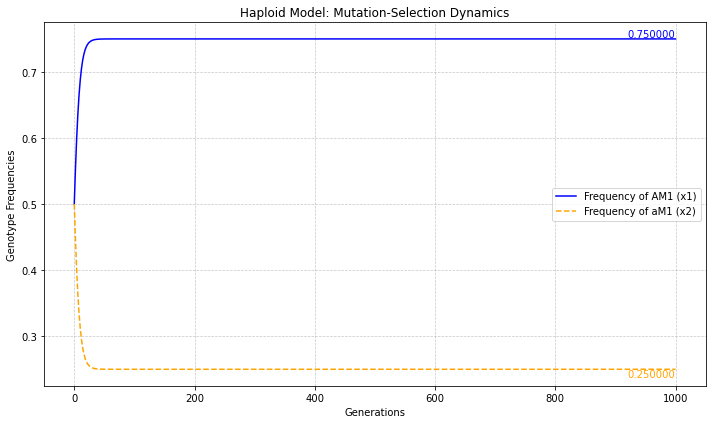

In [3]:
# Parameters
x1_initial = 0.5  # Initial frequency of AM1
u1 = 0.05  # Mutation rate from A to a
v1 = 0.  # Mutation rate from a to A
s = 0.2  # Selection coefficient against a
generations = 1000  # Number of generations to simulate

# Run the simulation
x1_history = simulate_haploid_selection_mutation(x1_initial, u1, v1, s, generations)

# Determine the convergent values
convergent_value_AM1 = x1_history[-1]  # Final value of AM1
convergent_value_aM1 = 1 - convergent_value_AM1  # Final value of aM1

plt.figure(figsize=(10, 6))
plt.plot(x1_history, label="Frequency of AM1 (x1)", color='blue')
plt.plot([1 - x for x in x1_history], label="Frequency of aM1 (x2)", linestyle='--', color='orange')

# Add labels for the convergent values with more decimal places
plt.text(len(x1_history) - 1, convergent_value_AM1, f'{convergent_value_AM1:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1_history) - 1, convergent_value_aM1, f'{convergent_value_aM1:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xlabel("Generations")
plt.ylabel("Genotype Frequencies")
plt.title("Haploid Model: Mutation-Selection Dynamics")
plt.legend()
plt.tight_layout() 
plt.show()

#### Two Allele Modifier

In [3]:
def haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma=0.0):
    """
    Simulate the genetic model with given parameters.

    Parameters:
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    sigma : float - Standard deviation for stochastic u2
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    Frequencies of x1, x2, x3, x4 over generations and a plot of their trajectories.
    """
    # Fitness values
    W_A = 1 
    W_a = 1 - s

    # Arrays to store frequencies over generations
    x1 = np.zeros(generations)
    x2 = np.zeros(generations)
    x3 = np.zeros(generations)
    x4 = np.zeros(generations)

    # Initialize frequencies
    x1[0], x2[0], x3[0], x4[0] = x1_init, x2_init, x3_init, x4_init

    # Function to calculate mean fitness
    def mean_fitness(x1, x2, x3, x4, W_A, W_a):
        return x1 * W_A + x2 * W_a + x3 * W_A + x4 * W_a

    # Evolution over generations
    for t in range(1, generations):
    
        a, b = (0 - u2) / sigma, (1 - u2) / sigma
        u2_t = truncnorm.rvs(a, b, loc=u2, scale=sigma)

        # Calculate mean fitness
        W_mean = mean_fitness(x1[t-1], x2[t-1], x3[t-1], x4[t-1], W_A, W_a)

        # After selection
        x1_prime = x1[t-1] * W_A / W_mean
        x2_prime = x2[t-1] * W_a / W_mean
        x3_prime = x3[t-1] * W_A / W_mean
        x4_prime = x4[t-1] * W_a / W_mean

        # After mutation
        x1[t] = x1_prime * (1 - u1) + x2_prime * v1
        x2[t] = x2_prime * (1 - v1) + x1_prime * u1
        x3[t] = x3_prime * (1 - u2_t) + x4_prime * v2
        x4[t] = x4_prime * (1 - v2) + x3_prime * u2_t

        total = x1[t] + x2[t] + x3[t] + x4[t]
        x1[t] /= total
        x2[t] /= total
        x3[t] /= total
        x4[t] /= total


    return x1, x2, x3, x4


0.7499999999999997 0.25000000000000033 0.0 0.0


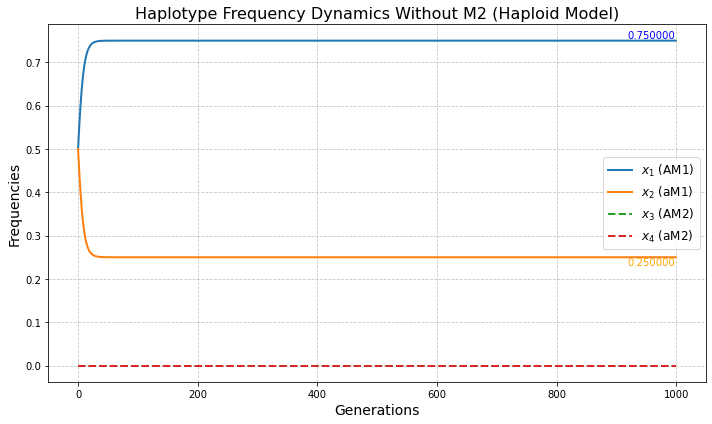

In [5]:
# Just checking it works as predicted
# Define the parameters for the simulation where M2 is not introduced yet
generations = 1000
s = 0.2  # Selection coefficient
u1 = 0.05  # Forward mutation rate for M1
u2 = 0.0  # Forward mutation rate for M2 (not introduced yet)
v1 = 0.0  # Back mutation rate for M1
v2 = 0.0  # Back mutation rate for M2
x1_init = 0.5  # Initial frequency of AM1
x2_init = 0.5  # Initial frequency of aM1
x3_init = 0.0  # Initial frequency of AM2 (not introduced)
x4_init = 0.0  # Initial frequency of aM2 (not introduced)
sigma_2 = 0.0  # No stochasticity in u2

# Simulate the model
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=generations,
    s=s,
    u1=u1,
    u2=u2,
    v1=v1,
    v2=v2,
    x1_init=x1_init,
    x2_init=x2_init,
    x3_init=x3_init,
    x4_init=x4_init,
    sigma_2=sigma_2
)
print(x1[-1], x2[-1], x3[-1], x4[-1])

# Plot the frequencies over generations
plt.figure(figsize=(10, 6))
plt.plot(np.arange(generations), x1, label=r'$x_1$ (AM1)', linewidth=2)
plt.plot(np.arange(generations), x2, label=r'$x_2$ (aM1)', linewidth=2)
plt.plot(np.arange(generations), x3, label=r'$x_3$ (AM2)', linewidth=2, linestyle='--')
plt.plot(np.arange(generations), x4, label=r'$x_4$ (aM2)', linewidth=2, linestyle='--')

# Add labels for the convergent values with more decimal places
plt.text(len(x1) - 1, x1[-1], f'{x1[-1]:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1) - 1, x2[-1], f'{x2[-1]:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

# Adding labels and legend
plt.xlabel('Generations', fontsize=14)
plt.ylabel('Frequencies', fontsize=14)
plt.title('Haplotype Frequency Dynamics Without M2 (Haploid Model)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


### Figure 2

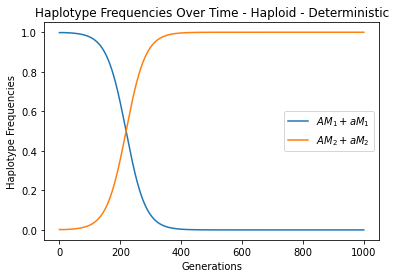

In [29]:
# Deterministic
t= 0.001
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=1000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

# Plot results
plt.plot(x1+x2, label="$AM_1 + aM_1$")
plt.plot(x3+x4, label="$AM_2 + aM_2$")
plt.xlabel("Generations")
plt.ylabel("Haplotype Frequencies")
plt.title("Haplotype Frequencies Over Time - Haploid - Deterministic")
plt.legend()
plt.show()

In [7]:
def plot_grouped_frequencies(x1, x2, x3, x4):
    """
    Plot the grouped frequencies for M1 (AM1 + aM1) and M2 (AM2 + aM2) based on the original haplotype frequencies.

    Parameters:
    x1, x2, x3, x4 : numpy arrays - Frequencies of AM1, aM1, AM2, and aM2 over generations.
    """
    # Calculate grouped frequencies
    M1 = x1 + x2  # M1 = AM1 + aM1
    M2 = x3 + x4  # M2 = AM2 + aM2

    # Plot grouped results
    plt.plot(M1, label="M1 (AM1 + aM1)")
    plt.plot(M2, label="M2 (AM2 + aM2)")
    plt.xlabel("Generations")
    plt.ylabel("Frequencies")
    plt.title("Grouped Genotype Frequencies Over Time")
    plt.legend()
    plt.show()

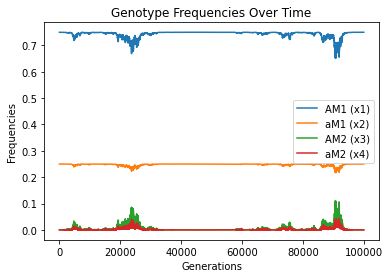

In [8]:
# Stochastic 
t=0.0001
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=100000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t,
    sigma_2 = 0.0515
)
 # Plot results
plt.plot(x1, label="AM1 (x1)")
plt.plot(x2, label="aM1 (x2)")
plt.plot(x3, label="AM2 (x3)")
plt.plot(x4, label="aM2 (x4)")
plt.xlabel("Generations")
plt.ylabel("Frequencies")
plt.title("Genotype Frequencies Over Time")
plt.legend()
plt.show()

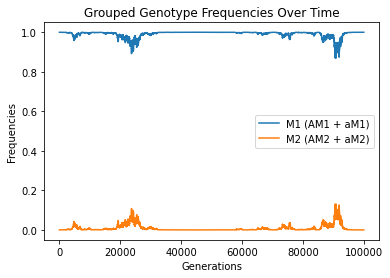

In [9]:
plot_grouped_frequencies(x1, x2, x3, x4)

In [105]:
def plot_final_frequencies_with_sigma(
    sigma_values, generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init
):
    """
    Run haploid_mutation_2m for n steps with a range of sigma_2 values
    and plot final frequencies of M1 and M2.

    Parameters:
    sigma_values : numpy array - Range of sigma_2 values to test
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    None (plots the results directly).
    """
    final_M1 = []
    final_M2 = []

    for sigma in sigma_values:
        # Run haploid_mutation_2m for the given sigma_2
        x1, x2, x3, x4 = haploid_mutation_2m(
            generations=generations,
            s=s,
            u1=u1,
            u2=u2,
            v1=v1,
            v2=v2,
            x1_init=x1_init,
            x2_init=x2_init,
            x3_init=x3_init,
            x4_init=x4_init,
            sigma=sigma,
        )

        # Compute final grouped frequencies
        M1_final = x1[-1] + x2[-1]
        M2_final = x3[-1] + x4[-1]

        final_M1.append(M1_final)
        final_M2.append(M2_final)

    # Plot results
    plt.plot(sigma_values, final_M1, label="M1 (AM1 + aM1)")
    plt.plot(sigma_values, final_M2, label="M2 (AM2 + aM2)")
    plt.xlabel(r"$\sigma$")
    plt.ylabel("Frequencies after 100000 Steps")
    plt.title("Final Frequencies vs. $\sigma_2$")
    plt.legend()
    plt.show()



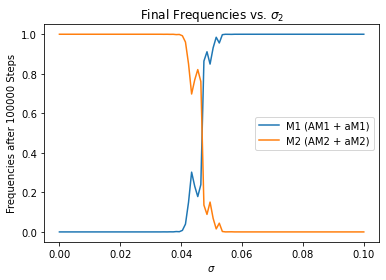

In [109]:
t=0.01
sigma_values = np.linspace(0, 0.1, 100)
plot_final_frequencies_with_sigma(
    sigma_values=sigma_values,
    generations=1000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

### Figure 3

/var/folders/bd/8y0v0_fn5nb59gjxm0ydc3vh0000gn/T/ipykernel_71183/1603078232.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  a, b = (0 - u2) / sigma, (1 - u2) / sigma


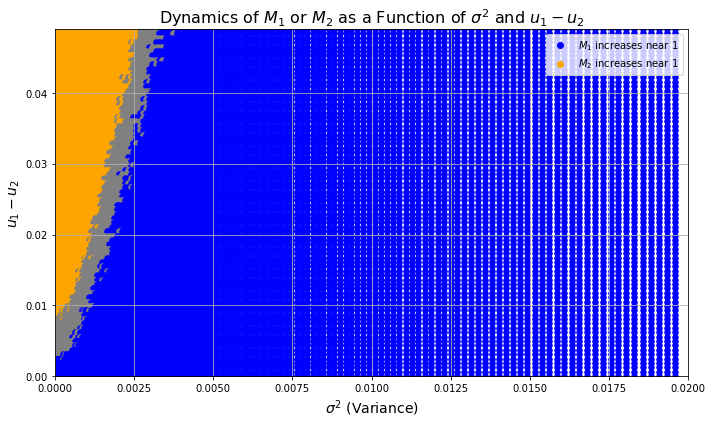

In [14]:

# Parameters
generations = 1000
u1 = 0.05
u2_values = np.linspace(0.001, 0.05, 80)
sigma_u_values = np.linspace(0, 0.14, 150)
s, v1, v2, dot_size = 0.2, 0.0, 0.0, 30

 # Generate random t1 and t2 ensuring sum is 1
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.75 - total_t / 2
x2_init = 0.25 - total_t / 2
x3_init = t1
x4_init = t2

# Plot setup
plt.figure(figsize=(10, 6))

for u2 in u2_values:
    for sigma in sigma_u_values:
        x1, x2, x3, x4 = haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma)
        M1_final, M2_final = x1[-1] + x2[-1], x3[-1] + x4[-1]
        
        color = 'blue' if M1_final > 0.95 else 'orange' if M2_final > 0.95 else 'gray'
        plt.scatter(sigma**2, u1 - u2, color=color, s=dot_size)


plt.xlabel(r'$\sigma^2$ (Variance)', fontsize=14)
plt.ylabel(r'$u_1 - u_2$', fontsize=14)
plt.title(r'Dynamics of $M_1$ or $M_2$ as a Function of $\sigma^2$ and $u_1 - u_2$', fontsize=16)
plt.scatter([], [], color='blue', label=r'$M_1$ increases near 1')
plt.scatter([], [], color='orange', label=r'$M_2$ increases near 1')
plt.legend()
plt.grid(True)
plt.xlim(0,0.02)
plt.ylim(0, 0.049)  
plt.tight_layout()
plt.show()

## Different Distributions

### Figure 4

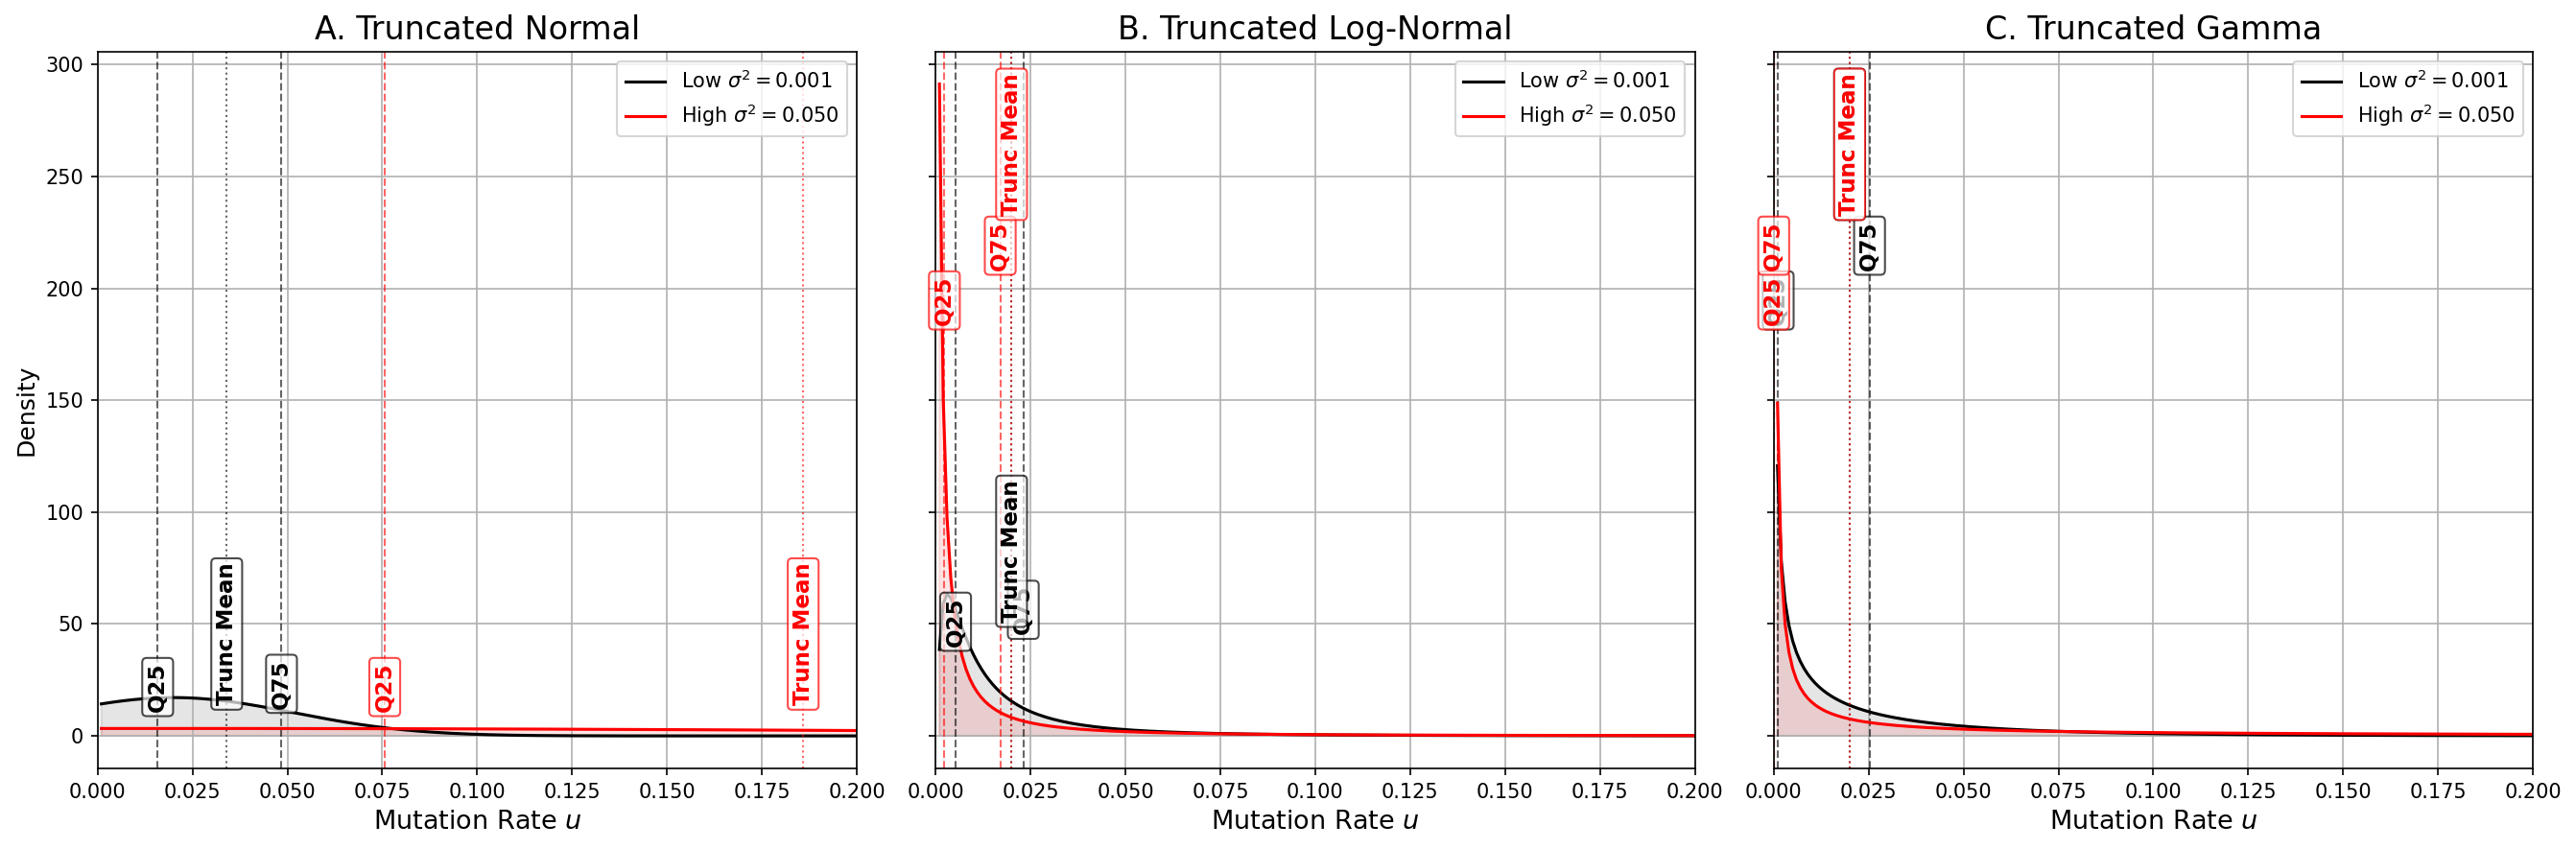

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, gamma

# Parameters
x_values = np.linspace(0.001, 1, 1000)
sigma_u_values = [0.001, 0.005, 0.01, 0.025, 0.05]
u2_fixed = 0.02

# Improved annotation function
def plot_lines(ax, values, labels, color, yscales):
    base_y = ax.get_ylim()[1]
    for val, desc, yscale in zip(values, labels, yscales):
        linestyle = '--' if desc != 'Trunc Mean' else ':'
        ax.axvline(val, color=color, linestyle=linestyle, linewidth=1, alpha=0.6)
        ax.annotate(desc, xy=(val, base_y * yscale), rotation=90, fontsize=11,
                    fontweight='bold', color=color, ha='center', va='bottom',
                    bbox=dict(boxstyle="round,pad=0.2", fc='white', ec=color, alpha=0.7))

# Create plot with higher resolution for clarity
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150, sharex=True, sharey=True)

# Truncated Normal
for label, sigma2, color in [("Low", sigma_u_values[0], 'black'), ("High", sigma_u_values[-1], 'red')]:
    sigma = np.sqrt(sigma2)
    a, b = (0 - u2_fixed) / sigma, (1 - u2_fixed) / sigma
    dist = truncnorm(a, b, loc=u2_fixed, scale=sigma)
    y = dist.pdf(x_values)
    axes[0].fill_between(x_values, 0, y, color=color, alpha=0.1)
    axes[0].plot(x_values, y, color=color, label=f"{label} $\sigma^2={sigma2:.3f}$")
    q25, q75 = dist.ppf([0.25, 0.75])
    mean = dist.mean()
    plot_lines(axes[0], [q25, q75, mean], ['Q25', 'Q75', 'Trunc Mean'], color, [0.60, 0.68, 0.76])

axes[0].set_title("A. Truncated Normal", fontsize=16)
axes[0].set_xlabel("Mutation Rate $u$", fontsize=13)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].set_xlim(0, 0.2)
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Truncated Log-Normal
for label, sigma2, color in [("Low", sigma_u_values[0], 'black'), ("High", sigma_u_values[-1], 'red')]:
    sigma = np.sqrt(np.log(1 + sigma2 / u2_fixed**2))
    mu = np.log(u2_fixed) - 0.5 * sigma**2
    a, b = (np.log(0.001) - mu) / sigma, (np.log(1) - mu) / sigma
    dist = truncnorm(a, b, loc=mu, scale=sigma)
    log_x = np.log(x_values)
    y = dist.pdf(log_x) / x_values
    axes[1].fill_between(x_values, 0, y, color=color, alpha=0.1)
    axes[1].plot(x_values, y, color=color, label=f"{label} $\sigma^2={sigma2:.3f}$")
    q25, q75 = np.exp(dist.ppf([0.25, 0.75]))
    mean = np.exp(mu + 0.5 * sigma**2)
    plot_lines(axes[1], [q25, q75, mean], ['Q25', 'Q75', 'Trunc Mean'], color, [0.60, 0.68, 0.76])

axes[1].set_title("B. Truncated Log-Normal", fontsize=16)
axes[1].set_xlabel("Mutation Rate $u$", fontsize=13)
axes[1].set_xlim(0, 0.2)
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Truncated Gamma
for label, sigma2, color in [("Low", sigma_u_values[0], 'black'), ("High", sigma_u_values[-1], 'red')]:
    shape = (u2_fixed / np.sqrt(sigma2))**2
    scale = sigma2 / u2_fixed
    dist = gamma(a=shape, scale=scale)
    y_raw = dist.pdf(x_values)
    Z = dist.cdf(1) - dist.cdf(0.001)
    y = y_raw / Z
    axes[2].fill_between(x_values, 0, y, color=color, alpha=0.1)
    axes[2].plot(x_values, y, color=color, label=f"{label} $\sigma^2={sigma2:.3f}$")
    q25, q75 = [dist.ppf(q) for q in [0.25, 0.75]]
    mean = dist.mean()
    plot_lines(axes[2], [q25, q75, mean], ['Q25', 'Q75', 'Trunc Mean'], color, [0.60, 0.68, 0.76])

axes[2].set_title("C. Truncated Gamma", fontsize=16)
axes[2].set_xlabel("Mutation Rate $u$", fontsize=13)
axes[2].set_xlim(0, 0.2)
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Figure 5

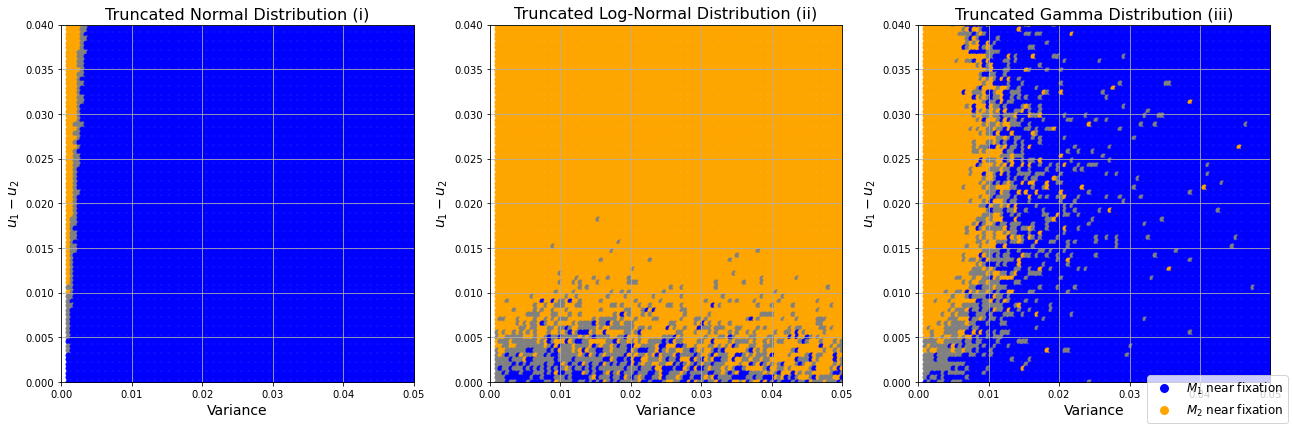

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# ---------- Simulation Function ----------
def simulate_stochastic_mutation(
    variance,
    u2_mean,
    initial_frequencies,
    timesteps=1000,
    u1=0.05,
    s=0.2,
    v1=0.0,
    distribution="truncated_normal",
    seed=None,
):
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))
    u2_samples = []

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]

        # --- Sample mutation rate ---
        if variance == 0:
            u2_stochastic = u2_mean

        elif distribution == "truncated_normal":
            sigma_u = np.sqrt(variance)
            a, b = (0 - u2_mean) / sigma_u, (1 - u2_mean) / sigma_u
            u2_stochastic = truncnorm.rvs(a, b, loc=u2_mean, scale=sigma_u, random_state=rng)

        elif distribution == "log_normal":
            sigma = np.sqrt(np.log(1 + variance / u2_mean**2))
            mu = np.log(u2_mean) - 0.5 * sigma**2
            a, b = (np.log(1e-5) - mu) / sigma, (np.log(1.0) - mu) / sigma
            log_sample = truncnorm.rvs(a, b, loc=mu, scale=sigma, random_state=rng)
            u2_stochastic = np.exp(log_sample)

        elif distribution == "gamma":
            shape = u2_mean**2 / variance
            scale = variance / u2_mean
            u2_stochastic = None
            for _ in range(1000):
                sample = rng.gamma(shape, scale)
                if 1e-8 <= sample <= 1.0:
                    u2_stochastic = sample
                    break
            if u2_stochastic is None:
                u2_stochastic = u2_mean

        else:
            raise ValueError("Unsupported distribution type.")

        u2_stochastic = np.clip(u2_stochastic, 1e-8, 1.0)
        u2_samples.append(u2_stochastic)

        # --- Selection ---
        W_A, W_a = 1.0, 1.0 - s
        w_bar = x1 * W_A + x2 * W_a + x3 * W_A + x4 * W_a
        x1_prime = x1 * W_A / w_bar
        x2_prime = x2 * W_a / w_bar
        x3_prime = x3 * W_A / w_bar
        x4_prime = x4 * W_a / w_bar

        # --- Mutation ---
        x1 = x1_prime * (1 - u1) + x2_prime * v1
        x2 = x2_prime * (1 - v1) + x1_prime * u1
        x3 = x3_prime * (1 - u2_stochastic) + x4_prime * v1
        x4 = x4_prime * (1 - v1) + x3_prime * u2_stochastic

        # Normalize
        total = x1 + x2 + x3 + x4
        x1, x2, x3, x4 = np.clip(np.array([x1, x2, x3, x4]) / total, 0, 1)

    return np.round(frequencies, 6), np.var(u2_samples), np.mean(u2_samples)


# ---------- Simulation Grid ----------
generations = 1000
u1 = 0.05
s, v1 = 0.2, 0.0
dot_size = 25

# Random perturbation to match diploid script
t1, t2 = np.random.uniform(0, 0.01, 2)
x1_init = 0.76 - (t1 + t2) / 2
x2_init = t1
x3_init = 0.24 - (t1 + t2) / 2
x4_init = t2
initial_freqs = [x1_init, x2_init, x3_init, x4_init]

# Grid
u2_mean_values = np.linspace(0.01, 0.05, 80)  # match diploid domain
variance_values = np.linspace(0.001, 0.05, 100)

distributions = ["truncated_normal", "log_normal", "gamma"]
titles = [
    "Truncated Normal Distribution (i)",
    "Truncated Log-Normal Distribution (ii)",
    "Truncated Gamma Distribution (iii)"
]

# ---------- Plotting ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]

    for u2_mean in u2_mean_values:
        for variance in variance_values:
            freqs, realized_var, mean_u2 = simulate_stochastic_mutation(
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=initial_freqs,
                timesteps=generations,
                u1=u1,
                s=s,
                v1=v1,
                distribution=distribution,
            )

            # Averaging last 50 generations (robustness fix)
            M1_final = freqs[-50:, 0].mean() + freqs[-50:, 1].mean()
            M2_final = freqs[-50:, 2].mean() + freqs[-50:, 3].mean()

            if M1_final > 0.95:
                color = "blue"
            elif M2_final > 0.95:
                color = "orange"
            else:
                color = "gray"

            x_val = variance
            y_val = u1 - u2_mean  # match diploid axis

            if 0 <= x_val <= 0.05 and 0 <= y_val <= 0.04:
                ax.scatter(x_val, y_val, color=color, s=dot_size)

    ax.set_xlabel("Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)
    ax.set_xlim(0, 0.05)
    ax.set_ylim(0, 0.04)

# Legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()


## Lyapunov estimations

### Figure: trunc_normal_lyapunov_thresh

/var/folders/bd/8y0v0_fn5nb59gjxm0ydc3vh0000gn/T/ipykernel_71183/1603078232.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  a, b = (0 - u2) / sigma, (1 - u2) / sigma


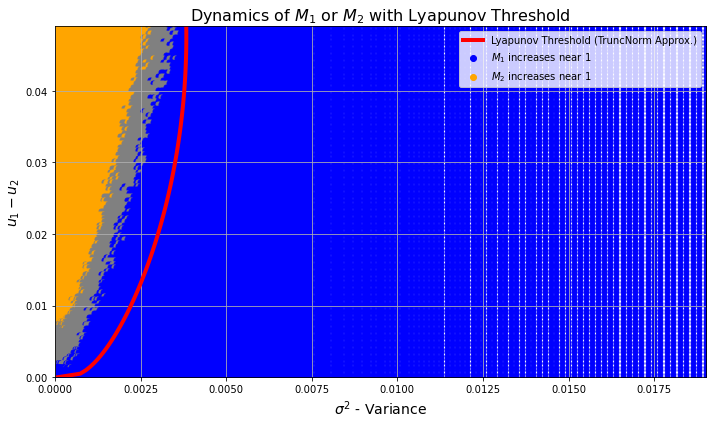

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Taylor-approximated critical variance threshold
def sigma2_crit_taylor(mu, u1):
    return -2 * np.log(1 - u1) - 2 * mu - mu**2

# Truncated normal approximation of E[log(1 - u)]
def expected_log1minus_u_truncnorm(mu, sigma):
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    phi_a = norm.pdf(a)
    phi_b = norm.pdf(b)
    E_u = mu + (phi_a - phi_b) / Z * sigma
    E_u2 = mu**2 + sigma**2 + (a * phi_a - b * phi_b) / Z * sigma
    return -E_u - 0.5 * E_u2

# Inverted form to solve for sigma^2_crit from E[log(1 - u)] = log(1 - u1)
def sigma2_crit_truncnorm(mu, u1):
    target = np.log(1 - u1)
    def objective(sigma2):
        sigma = np.sqrt(sigma2)
        return expected_log1minus_u_truncnorm(mu, sigma) - target
    # Try to find root via bisection
    from scipy.optimize import brentq
    try:
        return brentq(objective, 1e-6, 0.05)
    except ValueError:
        return np.nan

# Parameters
generations = 1000
u1 = 0.05
u2_values = np.linspace(0.001, 0.05, 100)
sigma_u_values = np.linspace(0, 0.14, 200)
s, v1, v2, dot_size = 0.2, 0.0, 0.0, 25

# Random initial frequencies
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.75 - total_t / 2
x2_init = 0.25 - total_t / 2
x3_init = t1
x4_init = t2

# Plot setup
plt.figure(figsize=(10, 6))

# Simulate system dynamics
for u2 in u2_values:
    for sigma in sigma_u_values:
        x1, x2, x3, x4 = haploid_mutation_2m(
            generations, s, u1, u2, v1, v2,
            x1_init, x2_init, x3_init, x4_init, sigma
        )
        M1_final = x1[-1] + x2[-1]
        M2_final = x3[-1] + x4[-1]
        color = 'blue' if M1_final > 0.95 else 'orange' if M2_final > 0.95 else 'gray'
        plt.scatter(sigma**2, u1 - u2, color=color, s=dot_size)

# # Plot Taylor-approximation threshold curve
# sigma2_crit_curve_taylor = [sigma2_crit_taylor(mu=u2, u1=u1) for u2 in u2_values]
# valid_indices_taylor = [i for i, val in enumerate(sigma2_crit_curve_taylor) if val > 0]
# plt.plot(
#     [sigma2_crit_curve_taylor[i] for i in valid_indices_taylor],
#     [u1 - u2_values[i] for i in valid_indices_taylor],
#     color='red', linestyle='--', linewidth=2,
#     label='Lyapunov Threshold (Taylor Approx.)'
# )

# Plot truncated normal corrected threshold curve
sigma2_crit_curve_truncnorm = [sigma2_crit_truncnorm(mu=u2, u1=u1) for u2 in u2_values]
valid_indices_truncnorm = [i for i, val in enumerate(sigma2_crit_curve_truncnorm) if not np.isnan(val)]
plt.plot(
    [sigma2_crit_curve_truncnorm[i] for i in valid_indices_truncnorm],
    [u1 - u2_values[i] for i in valid_indices_truncnorm],
    color='red', linestyle='-', linewidth=4,
    label='Lyapunov Threshold (TruncNorm Approx.)'
)

plt.xlabel(r'$\sigma^2$ - Variance', fontsize=14)
plt.ylabel(r'$u_1 - u_2$', fontsize=14)
plt.title('Dynamics of $M_1$ or $M_2$ with Lyapunov Threshold', fontsize=16)
plt.scatter([], [], color='blue', label=r'$M_1$ increases near 1')
plt.scatter([], [], color='orange', label=r'$M_2$ increases near 1')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.019)
plt.ylim(0, 0.049)
plt.tight_layout()
plt.show()


### Fig: f5b_var_lyap_dist

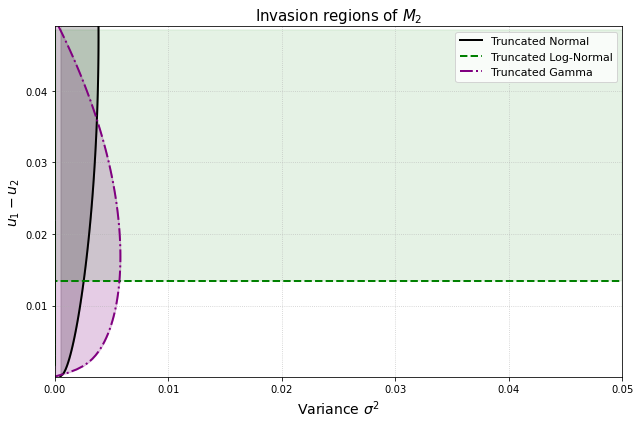

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad

# ---------------- Parameters ----------------
u1 = 0.05
mu_vals = np.linspace(0.001, u1 - 1e-4, 100)
delta_vals = u1 - mu_vals

# ---------------- Truncated Normal ----------------
def expected_log1minus_u_truncnorm(mu, sigma):
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    phi_a = norm.pdf(a)
    phi_b = norm.pdf(b)
    E_u = mu + (phi_a - phi_b) / Z * sigma
    E_u2 = mu**2 + sigma**2 + (a * phi_a - b * phi_b) / Z * sigma
    return -E_u - 0.5 * E_u2

def sigma2_crit_truncnorm(mu, u1):
    target = np.log(1 - u1)
    def objective(sigma2):
        if sigma2 <= 0:
            return np.inf
        sigma = np.sqrt(sigma2)
        val = expected_log1minus_u_truncnorm(mu, sigma)
        return val - target
    try:
        return brentq(objective, 1e-6, 0.05)
    except Exception:
        return np.nan

critvals_truncnorm = np.array([sigma2_crit_truncnorm(mu, u1) for mu in mu_vals])

# ---------------- Truncated Log-Normal ----------------
def expected_log1minus_u_trunclognorm(mu, sigma, eps=1e-8):
    a, b = np.log(eps), 0
    def lognorm_pdf(logu):
        u = np.exp(logu)
        z = (logu - mu) / sigma
        return norm.pdf(z) / (sigma * u)
    def integrand(logu):
        u = np.exp(logu)
        return np.log(1 - u) * lognorm_pdf(logu)
    Z, _ = quad(lognorm_pdf, a, b, limit=200)
    if Z == 0 or not np.isfinite(Z):
        return np.nan
    integral, _ = quad(integrand, a, b, limit=200)
    return integral / Z

def realspace_variance_trunclognorm(mu, sigma, eps=1e-8):
    a, b = np.log(eps), 0
    def lognorm_pdf(logu):
        u = np.exp(logu)
        z = (logu - mu) / sigma
        return norm.pdf(z) / (sigma * u)
    def integrand1(logu):
        return np.exp(logu) * lognorm_pdf(logu)
    def integrand2(logu):
        return np.exp(2 * logu) * lognorm_pdf(logu)
    Z, _ = quad(lognorm_pdf, a, b, limit=200)
    E_u, _ = quad(integrand1, a, b, limit=200)
    E_u2, _ = quad(integrand2, a, b, limit=200)
    E_u /= Z
    E_u2 /= Z
    return E_u2 - E_u**2 if E_u2 > E_u**2 else np.nan

def realspace_variance_crit_lognorm(bar_u, u1, max_sigma=1.0, step=0.001):
    target = np.log(1 - u1)
    for sigma in np.arange(step, max_sigma, step):
        mu = np.log(bar_u) - 0.5 * sigma**2
        val = expected_log1minus_u_trunclognorm(mu, sigma)
        if val > target:
            return realspace_variance_trunclognorm(mu, sigma)
    return np.nan

critvals_lognorm = np.array([realspace_variance_crit_lognorm(mu, u1) for mu in mu_vals])

# ---------------- Truncated Gamma ----------------
def expected_log1minus_u_gamma(mu, sigma2, eps=1e-4):
    alpha = mu**2 / sigma2
    beta = mu / sigma2
    try:
        Z, _ = quad(lambda u: u**(alpha - 1) * np.exp(-beta * u), eps, 1, limit=200)
        if Z == 0 or not np.isfinite(Z):
            return np.nan
        def integrand(u):
            return np.log(1 - u) * u**(alpha - 1) * np.exp(-beta * u)
        integral, _ = quad(integrand, eps, 1, limit=200)
        return integral / Z
    except Exception:
        return np.nan

def sigma2_crit_gamma(mu, u1, eps=1e-4):
    target = np.log(1 - u1)
    def objective(sigma2):
        if sigma2 <= 0:
            return np.inf
        val = expected_log1minus_u_gamma(mu, sigma2, eps)
        return val - target if np.isfinite(val) else np.inf
    try:
        return brentq(objective, 1e-6, 0.2)
    except Exception:
        return np.nan

critvals_gamma = np.array([sigma2_crit_gamma(mu, u1) for mu in mu_vals])

# ---------------- Plotting ----------------
valid_truncnorm = np.isfinite(critvals_truncnorm)
valid_lognorm = np.isfinite(critvals_lognorm)
valid_gamma = np.isfinite(critvals_gamma)

# Sort log-normal for single-use in plot and shading
idx_lognorm = np.argsort(critvals_lognorm[valid_lognorm])
x_lognorm_sorted = critvals_lognorm[valid_lognorm][idx_lognorm]
y_lognorm_sorted = delta_vals[valid_lognorm][idx_lognorm]

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

# Critical curves
ax.plot(critvals_truncnorm[valid_truncnorm], delta_vals[valid_truncnorm],
        color="black", lw=2, label="Truncated Normal")
ax.plot(x_lognorm_sorted, y_lognorm_sorted,
        color="green", lw=2, linestyle='--', label="Truncated Log-Normal")
ax.plot(critvals_gamma[valid_gamma], delta_vals[valid_gamma],
        color="purple", lw=2, linestyle='-.', label="Truncated Gamma")

# Shading
xmax = 0.05
ax.fill_between(critvals_truncnorm[valid_truncnorm], delta_vals[valid_truncnorm],
                0.05, color='black', alpha=0.2)
ax.fill_between(critvals_gamma[valid_gamma], delta_vals[valid_gamma],
                0.05, color='purple', alpha=0.2)
ax.fill_betweenx(y_lognorm_sorted, x_lognorm_sorted, xmax,
                 color='green', alpha=0.1)

# Formatting
ax.set_xlabel(r"Variance $\sigma^2$", fontsize=14)
ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
ax.set_title("Invasion regions of $M_2$", fontsize=15)
ax.set_xlim(0, xmax)
ax.set_ylim(1e-10, 0.049)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(fontsize=11, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## Diploid

In [22]:
def simulate_stochastic_mutation(sigma_u, initial_frequencies, timesteps=1000, 
                                 u1=0.01, u2=0.02, u3=0.03, 
                                 s=0.2, R=0.1, seed=None):
    """
    Simulates diploid evolution with genotype-dependent mutation rates at A/a,
    modified by M1/M2 background. Only A → a mutation occurs (no back mutation).

    Haplotypes:
    - x1: AM1
    - x2: AM2
    - x3: aM1
    - x4: aM2

    Parameters:
    - sigma_u (float): Std dev of stochastic fluctuation on u2 (M1M2 genotype).
    - initial_frequencies (list): Initial haplotype frequencies [x1, x2, x3, x4].
    - timesteps (int): Number of generations to simulate.
    - u1, u2, u3 (float): A→a mutation rates for M1M1, M1M2, M2M2.
    - s (float): Selection coefficient (heterozygote fitness = 1 - s).
    - R (float): Recombination rate between A/a and M1/M2 loci.
    - seed (int or None): RNG seed for reproducibility.

    Returns:
    - np.ndarray: Trajectory of haplotype frequencies over time (timesteps × 4).
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")
    
    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = map(float, initial_frequencies)
    freq_traj = np.zeros((timesteps, 4))

    w11 = 1.0
    w12 = 1.0 - s
    w22 = 1.0 - 2 * s

    for t in range(timesteps):
        freq_traj[t] = [x1, x2, x3, x4]

        # Stochastic mutation rate for M1M2
        while True:
            u2_stochastic = u2 + rng.normal(0, sigma_u)
            if 0 <= u2_stochastic <= 1:
                break

        # Mean fitness
        w_bar = (
            (x1 + x2)**2 * w11 +
            2 * w12 * (x1 + x2) * (x3 + x4) +
            (x3 + x4)**2 * w22
        )

        # Selection and mutation dynamics
        x1_new = (1 - u1) * (x1**2 * w11 + x1 * x3 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))
        
        x2_new = (1 - u3) * (x2**2 * w11 + x2 * x4 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x2 * x3 * w12) + \
                 w12 * R * (x1 * x4 - x2 * x3)
        
        x3_new = x3**2 * w22 + x1 * x3 * w12 + x2 * x3 * w12 + x3 * x4 * w22 + \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u1 * (x1**2 * w11 + x1 * x3 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))
        
        x4_new = x4**2 * w22 + x1 * x4 * w12 + x2 * x4 * w12 + x3 * x4 * w22 - \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u3 * (x2**2 * w11 + x2 * x4 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x2 * x3 * w12 + w12 * R * (x1 * x4 - x2 * x3))

        # Normalize
        total = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = x1_new / total, x2_new / total, x3_new / total, x4_new / total

    return np.round(freq_traj, 6)


### Figure 6

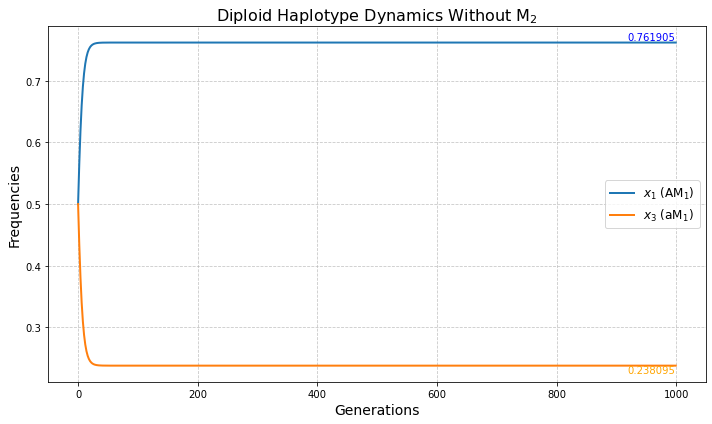

In [23]:
# Initial condition: only M1 alleles
# t1, t2 = np.random.uniform(0, 0.01, 2)
# total_t = t1 + t2
# initial_frequencies_no_M2 = [0.5 - total_t / 2, t1, 0.5 - total_t / 2, t2]

initial_frequencies_no_M2 = [0.5, 0, 0.5, 0]
timesteps = 1000

frequencies_no_M2 = simulate_stochastic_mutation(
    sigma_u=0.0,  # No stochasticity, M2 not present
    initial_frequencies=initial_frequencies_no_M2,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=58
)

plt.figure(figsize=(10, 6))
generations = np.arange(timesteps)
plt.plot(generations, frequencies_no_M2[:, 0], label=r'$x_1$ (AM$_1$)', linewidth=2)
plt.plot(generations, frequencies_no_M2[:, 2], label=r'$x_3$ (aM$_1$)', linewidth=2)

plt.text(timesteps - 1, frequencies_no_M2[-1, 0], f'{frequencies_no_M2[-1, 0]:.6f}', 
         va='bottom', ha='right', color='blue')
plt.text(timesteps - 1, frequencies_no_M2[-1, 2], f'{frequencies_no_M2[-1, 2]:.6f}', 
         va='top', ha='right', color='orange')

plt.xlabel("Generations", fontsize=14)
plt.ylabel("Frequencies", fontsize=14)
plt.title("Diploid Haplotype Dynamics Without M$_2$", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


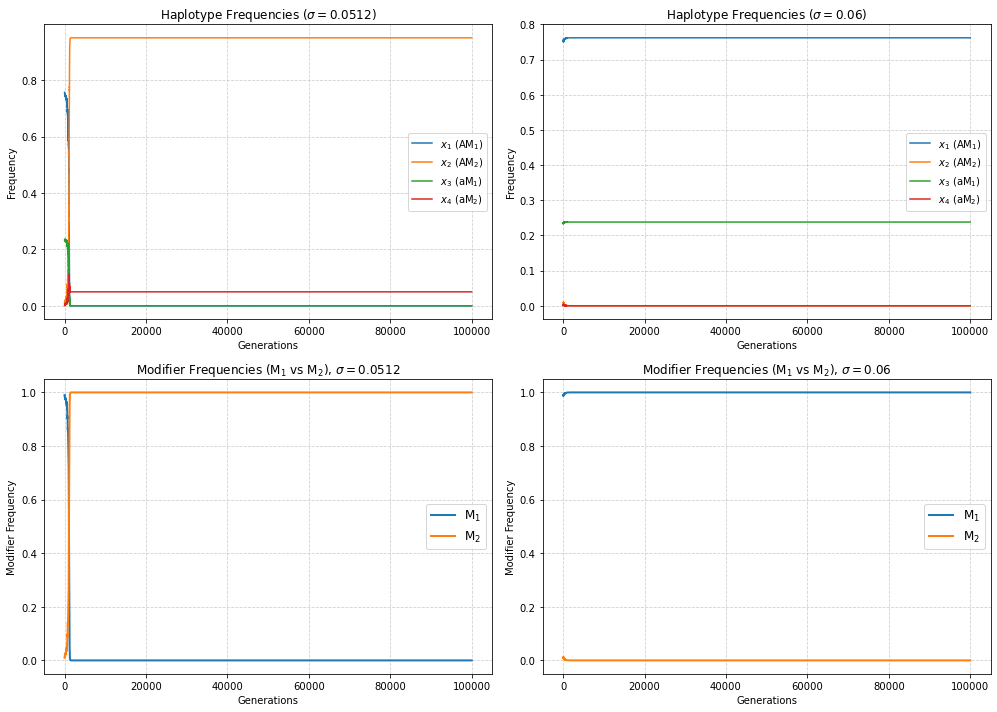

In [24]:
# Small M2 introduction
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
initial_frequencies = [0.761905 - total_t / 2, t1, 0.238095 - total_t / 2, t2]
timesteps = 100000

frequencies_sigma_0 = simulate_stochastic_mutation(
    sigma_u=0.0512,
    initial_frequencies=initial_frequencies,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=42
)

frequencies_sigma_01 = simulate_stochastic_mutation(
    sigma_u=0.06,
    initial_frequencies=initial_frequencies,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=42
)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = [r'$x_1$ (AM$_1$)', r'$x_2$ (AM$_2$)', r'$x_3$ (aM$_1$)', r'$x_4$ (aM$_2$)']
for i, label in enumerate(labels):
    axes[0, 0].plot(frequencies_sigma_0[:, i], label=label)
    axes[0, 1].plot(frequencies_sigma_01[:, i], label=label)

axes[0, 0].set_title(r"Haplotype Frequencies ($\sigma=0.0512$)")
axes[0, 1].set_title(r"Haplotype Frequencies ($\sigma=0.06$)")
for ax in axes[0]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

# Modifier frequencies
m1_sigma_0 = frequencies_sigma_0[:, 0] + frequencies_sigma_0[:, 2]
m2_sigma_0 = frequencies_sigma_0[:, 1] + frequencies_sigma_0[:, 3]
m1_sigma_01 = frequencies_sigma_01[:, 0] + frequencies_sigma_01[:, 2]
m2_sigma_01 = frequencies_sigma_01[:, 1] + frequencies_sigma_01[:, 3]

axes[1, 0].plot(m1_sigma_0, label="M$_1$", linewidth=2)
axes[1, 0].plot(m2_sigma_0, label="M$_2$", linewidth=2)
axes[1, 1].plot(m1_sigma_01, label="M$_1$", linewidth=2)
axes[1, 1].plot(m2_sigma_01, label="M$_2$", linewidth=2)

axes[1, 0].set_title(r"Modifier Frequencies (M$_1$ vs M$_2$), $\sigma=0.0512$")
axes[1, 1].set_title(r"Modifier Frequencies (M$_1$ vs M$_2$), $\sigma=0.06$")
for ax in axes[1]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Modifier Frequency")
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


### Figure 7

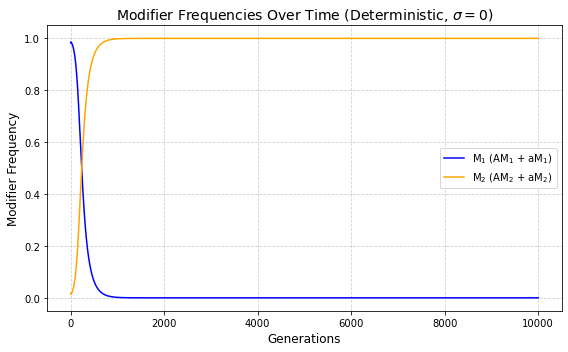

In [25]:
# Initial condition with small perturbation introducing M2
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
initial_frequencies = [0.761905 - total_t / 2, t1, 0.238095 - total_t / 2, t2]

# Run deterministic simulation (σ = 0)
frequencies = simulate_stochastic_mutation(
    sigma_u=0.0,
    initial_frequencies=initial_frequencies,
    timesteps=10000,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=10
)

# Plot total frequency of M1 and M2 haplotypes over time
plt.figure(figsize=(8, 5))
generations = np.arange(frequencies.shape[0])

plt.plot(generations, frequencies[:, 0] + frequencies[:, 2], label=r'M$_1$ (AM$_1$ + aM$_1$)', color='blue')
plt.plot(generations, frequencies[:, 1] + frequencies[:, 3], label=r'M$_2$ (AM$_2$ + aM$_2$)', color='orange')

plt.title("Modifier Frequencies Over Time (Deterministic, $\sigma=0$)", fontsize=14)
plt.xlabel("Generations", fontsize=12)
plt.ylabel("Modifier Frequency", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [26]:
def plot_final_frequencies(
    sigma_u_values,
    initial_frequencies,
    timesteps=10000,
    u1=0.05,
    u2=0.02,
    u3=0.01,
    s=0.2,
    R=0.0,
    seed=98
):
    """
    Plots final M1 and M2 modifier frequencies as a function of sigma_u
    (standard deviation in the stochastic mutation rate for M1M2 genotypes).

    Parameters:
    - sigma_u_values (array-like): List or array of σ_u values to simulate.
    - initial_frequencies (list of 4 floats): [AM1, AM2, aM1, aM2], must sum to 1.
    - timesteps (int): Number of generations to simulate.
    - u1, u2, u3 (float): Mutation rates A→a for M1M1, M1M2, M2M2 genotypes.
    - s (float): Selection coefficient (w_12 = 1-s, w_22 = 1-2s).
    - R (float): Recombination rate between loci.
    - seed (int): Random seed for reproducibility.

    Returns:
    - None. Displays the plot.
    """

    # Input validation
    if not isinstance(sigma_u_values, (list, np.ndarray)):
        raise TypeError("sigma_u_values must be a list or numpy array.")
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")
    
    final_frequencies = np.zeros((len(sigma_u_values), 4))

    for i, sigma_u in enumerate(sigma_u_values):
        freqs = simulate_stochastic_mutation(
            sigma_u=sigma_u,
            initial_frequencies=initial_frequencies,
            timesteps=timesteps,
            u1=u1, u2=u2, u3=u3,
            s=s, R=R,
            seed=seed
        )
        final_frequencies[i] = freqs[-1]

    # Correct grouping based on biological identity
    M1_final = final_frequencies[:, 0] + final_frequencies[:, 2]  # AM1 + aM1
    M2_final = final_frequencies[:, 1] + final_frequencies[:, 3]  # AM2 + aM2

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(sigma_u_values, M1_final, label=r'$M_1$ (AM$_1$ + aM$_1$)', linewidth=2)
    plt.plot(sigma_u_values, M2_final, label=r'$M_2$ (AM$_2$ + aM$_2$)', linewidth=2)

    plt.xlabel(r'$\sigma_u$', fontsize=14)
    plt.ylabel('Final Modifier Frequencies', fontsize=14)
    plt.title(r'Final Frequencies of $M_1$ and $M_2$ vs. $\sigma_u$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [27]:
def simulate_stochastic_mutation(sigma_u, variance, u2_mean, initial_frequencies,
                                 timesteps=1000, u1=0.05, u3=0.01, s=0.2, R=0,
                                 distribution="truncated_normal", seed=None):
    """
    Simulates diploid evolution with genotype-dependent stochastic mutation rates
    at the A/a locus, under different distributions for u2 (M1M2 genotype).
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]

        # --- Sample mutation rate ---
        if variance == 0:
            u2_stochastic = u2_mean

        elif distribution == "truncated_normal":
            sigma_u = np.sqrt(variance)
            a, b = (0 - u2_mean) / sigma_u, (1 - u2_mean) / sigma_u
            u2_stochastic = truncnorm.rvs(a, b, loc=u2_mean, scale=sigma_u, random_state=rng)

        elif distribution == "log_normal":
            sigma = np.sqrt(np.log(1 + variance / u2_mean**2))
            mu = np.log(u2_mean) - 0.5 * sigma**2
            a, b = (np.log(1e-5) - mu) / sigma, (np.log(1.0) - mu) / sigma
            log_sample = truncnorm.rvs(a, b, loc=mu, scale=sigma, random_state=rng)
            u2_stochastic = np.exp(log_sample)

        elif distribution == "gamma":
            shape = u2_mean**2 / variance
            scale = variance / u2_mean
            u2_stochastic = None
            for _ in range(1000):
                sample = rng.gamma(shape, scale)
                if 1e-8 <= sample <= 1.0:
                    u2_stochastic = sample
                    break
            if u2_stochastic is None:
                u2_stochastic = u2_mean

        else:
            raise ValueError("Unsupported distribution type.")

        # Mean fitness
        w11 = 1.0
        w12 = 1.0 - s
        w22 = 1.0 - 2 * s
        w_bar = ((x1 + x2)**2 * w11 +
                 2 * w12 * (x1 + x2) * (x3 + x4) +
                 (x3 + x4)**2 * w22)

        # Full model update
        x1_new = (1 - u1) * (x1**2 * w11 + x1 * x3 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))

        x2_new = (1 - u3) * (x2**2 * w11 + x2 * x4 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x2 * x3 * w12) + \
                 w12 * R * (x1 * x4 - x2 * x3)

        x3_new = x3**2 * w22 + x1 * x3 * w12 + x2 * x3 * w12 + x3 * x4 * w22 + \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u1 * (x1**2 * w11 + x1 * x3 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))

        x4_new = x4**2 * w22 + x1 * x4 * w12 + x2 * x4 * w12 + x3 * x4 * w22 - \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u3 * (x2**2 * w11 + x2 * x4 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x2 * x3 * w12 + w12 * R * (x1 * x4 - x2 * x3))

        # Normalize
        total = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = x1_new / total, x2_new / total, x3_new / total, x4_new / total

    return np.round(frequencies, 6), variance


### Figure 8

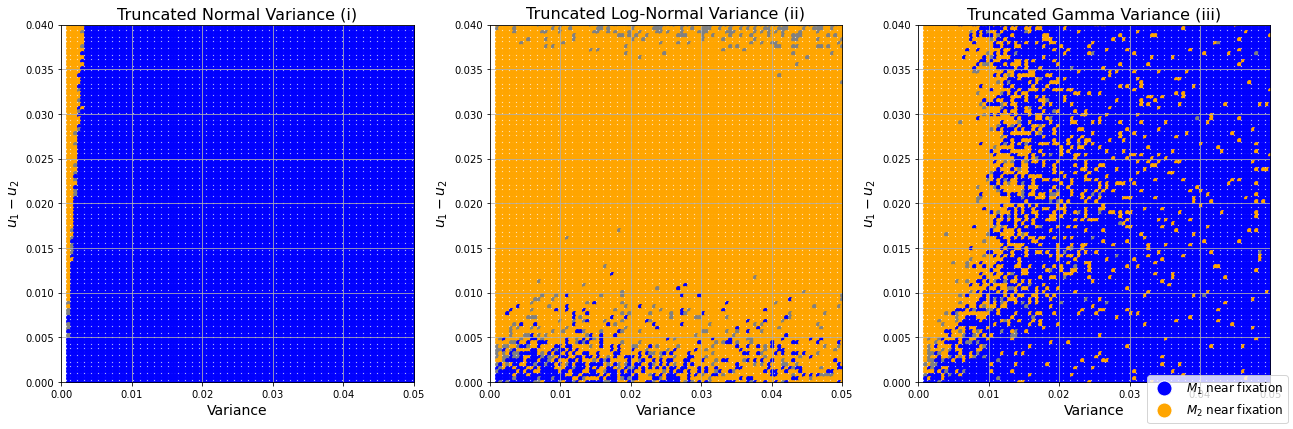

In [40]:
# Parameters
generations = 1000
u1 = 0.05
s = 0.2
R = 0.0
dot_size = 25

# Initial condition with random perturbation
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.76 - total_t / 2
x2_init = t1
x3_init = 0.24 - total_t / 2 
x4_init = t2

# Grid for plotting
u2_mean_values = np.linspace(0.01, u1, 100)
variance_values = np.linspace(0.001, 0.05, 100)

distributions = ["truncated_normal", "log_normal", "gamma"]
titles = [
    "Truncated Normal Variance (i)",
    "Truncated Log-Normal Variance (ii)",
    "Truncated Gamma Variance (iii)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]

    for u2_mean in u2_mean_values:
        for variance in variance_values:
            sigma_u = np.sqrt(variance) if distribution == "truncated_normal" else None

            freqs, actual_variance = simulate_stochastic_mutation(
                sigma_u=sigma_u,
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=[x1_init, x2_init, x3_init, x4_init],
                timesteps=generations,
                u1=u1,
                u3=0.01,
                s=s,
                R=R,
                distribution=distribution,
            )

            # Group by modifier allele
            M1_final = freqs[-1, 0] + freqs[-1, 2]  # AM1 + aM1
            M2_final = freqs[-1, 1] + freqs[-1, 3]  # AM2 + aM2

            # Assign color
            if M1_final > 0.95:
                color = "blue"
            elif M2_final > 0.95:
                color = "orange"
            else:
                color = "gray"

            ax.scatter(actual_variance, u1 - u2_mean, color=color, s=15)

    ax.set_xlabel("Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)
    ax.set_xlim(0, 0.05)
    ax.set_ylim(0, 0.04)
# Legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=15, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=15, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()


### Figure 9

In [50]:
# Re-import essentials after kernel reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad

# Redefine key parameters
u1 = 0.05
mu_vals = np.linspace(0.001, u1 - 1e-4, 100)
delta_vals = u1 - mu_vals

# --- Truncated Normal ---
def expected_log1minus_u_truncnorm(mu, sigma):
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    phi_a = norm.pdf(a)
    phi_b = norm.pdf(b)
    E_u = mu + (phi_a - phi_b) / Z * sigma
    E_u2 = mu**2 + sigma**2 + (a * phi_a - b * phi_b) / Z * sigma
    return -E_u - 0.5 * E_u2

def sigma2_crit_truncnorm(mu, u1):
    target = np.log(1 - u1)
    def objective(sigma2):
        if sigma2 <= 0:
            return np.inf
        sigma = np.sqrt(sigma2)
        val = expected_log1minus_u_truncnorm(mu, sigma)
        return val - target
    try:
        return brentq(objective, 1e-6, 0.05)
    except Exception:
        return np.nan

critvals_truncnorm = np.array([sigma2_crit_truncnorm(mu, u1) for mu in mu_vals])

# --- Truncated Log-Normal ---
def expected_log1minus_u_trunclognorm(mu, sigma, eps=1e-8):
    a, b = np.log(eps), 0
    def lognorm_pdf(logu):
        u = np.exp(logu)
        z = (logu - mu) / sigma
        return norm.pdf(z) / (sigma * u)
    def integrand(logu):
        u = np.exp(logu)
        return np.log(1 - u) * lognorm_pdf(logu)
    Z, _ = quad(lognorm_pdf, a, b, limit=200)
    if Z == 0 or not np.isfinite(Z):
        return np.nan
    integral, _ = quad(integrand, a, b, limit=200)
    return integral / Z

def realspace_variance_trunclognorm(mu, sigma, eps=1e-8):
    a, b = np.log(eps), 0
    def lognorm_pdf(logu):
        u = np.exp(logu)
        z = (logu - mu) / sigma
        return norm.pdf(z) / (sigma * u)
    def integrand1(logu):
        return np.exp(logu) * lognorm_pdf(logu)
    def integrand2(logu):
        return np.exp(2 * logu) * lognorm_pdf(logu)
    Z, _ = quad(lognorm_pdf, a, b, limit=200)
    E_u, _ = quad(integrand1, a, b, limit=200)
    E_u2, _ = quad(integrand2, a, b, limit=200)
    E_u /= Z
    E_u2 /= Z
    return E_u2 - E_u**2 if E_u2 > E_u**2 else np.nan

def realspace_variance_crit_lognorm(bar_u, u1, max_sigma=1.0, step=0.001):
    target = np.log(1 - u1)
    for sigma in np.arange(step, max_sigma, step):
        mu = np.log(bar_u) - 0.5 * sigma**2
        val = expected_log1minus_u_trunclognorm(mu, sigma)
        if val > target:
            return realspace_variance_trunclognorm(mu, sigma)
    return np.nan

critvals_lognorm = np.array([realspace_variance_crit_lognorm(mu, u1) for mu in mu_vals])

# --- Truncated Gamma ---
def expected_log1minus_u_gamma(mu, sigma2, eps=1e-4):
    alpha = mu**2 / sigma2
    beta = mu / sigma2
    try:
        Z, _ = quad(lambda u: u**(alpha - 1) * np.exp(-beta * u), eps, 1, limit=200)
        if Z == 0 or not np.isfinite(Z):
            return np.nan
        def integrand(u):
            return np.log(1 - u) * u**(alpha - 1) * np.exp(-beta * u)
        integral, _ = quad(integrand, eps, 1, limit=200)
        return integral / Z
    except Exception:
        return np.nan

def sigma2_crit_gamma(mu, u1, eps=1e-4):
    target = np.log(1 - u1)
    def objective(sigma2):
        if sigma2 <= 0:
            return np.inf
        val = expected_log1minus_u_gamma(mu, sigma2, eps)
        return val - target if np.isfinite(val) else np.inf
    try:
        return brentq(objective, 1e-6, 0.2)
    except Exception:
        return np.nan

critvals_gamma = np.array([sigma2_crit_gamma(mu, u1) for mu in mu_vals])


df_overlay = pd.DataFrame({
    "mu_vals": mu_vals,
    "delta_vals": delta_vals,
    "crit_truncnorm": critvals_truncnorm,
    "crit_lognorm": critvals_lognorm,
    "crit_gamma": critvals_gamma
})
if distribution == "truncated_normal":
        valid = np.isfinite(df_overlay["crit_truncnorm"])
        ax.plot(df_overlay["crit_truncnorm"][valid], df_overlay["delta_vals"][valid],
                color="red", lw=2.5, label="Lyapunov Threshold")

elif distribution == "log_normal":
    valid = np.isfinite(df_overlay["crit_lognorm"])
    x = df_overlay["crit_lognorm"][valid].to_numpy()
    y = df_overlay["delta_vals"][valid].to_numpy()
    sort_idx = np.argsort(x)
    ax.plot(x[sort_idx], y[sort_idx],
            color="green", lw=2.5, label="Lyapunov Threshold")

elif distribution == "gamma":
    valid = np.isfinite(df_overlay["crit_gamma"])
    ax.plot(df_overlay["crit_gamma"][valid], df_overlay["delta_vals"][valid],
            color="purple", lw=2.5, label="Lyapunov Threshold")


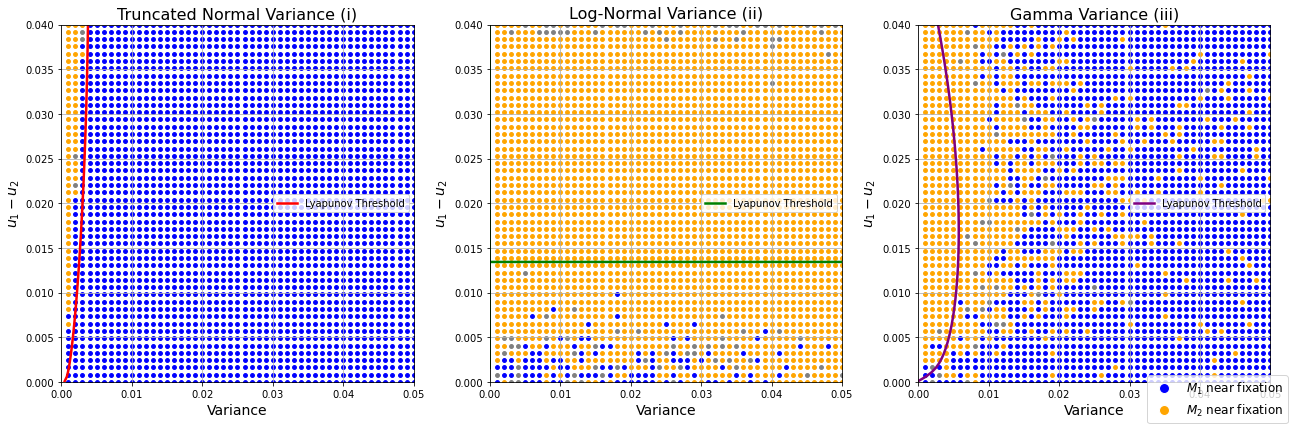

In [51]:
import matplotlib.pyplot as plt

# --- Final Plotting Code with Corrected Single Log-Normal Line ---
generations = 1000
u1 = 0.05
s = 0.2
R = 0.0

u2_mean_values = np.linspace(0.01, u1, 50)
variance_values = np.linspace(0.001, 0.05, 50)

distributions = ["truncated_normal", "log_normal", "gamma"]
titles = [
    "Truncated Normal Variance (i)",
    "Log-Normal Variance (ii)",
    "Gamma Variance (iii)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]

    for u2_mean in u2_mean_values:
        for variance in variance_values:
            sigma_u = np.sqrt(variance) if distribution == "truncated_normal" else None

            freqs, actual_variance = simulate_stochastic_mutation(
                sigma_u=sigma_u,
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=[0.75, 0.01, 0.23, 0.01],
                timesteps=generations,
                u1=u1,
                u3=0.01,
                s=s,
                R=R,
                distribution=distribution,
            )

            M1_final = freqs[-1, 0] + freqs[-1, 2]
            M2_final = freqs[-1, 1] + freqs[-1, 3]

            color = (
                "blue" if M1_final > 0.95 else
                "orange" if M2_final > 0.95 else
                "gray"
            )
            ax.scatter(actual_variance, u1 - u2_mean, color=color, s=15)

    # Overlay Lyapunov Threshold Curve (only sorted for log-normal)
    if distribution == "truncated_normal":
        valid = np.isfinite(df_overlay["crit_truncnorm"])
        ax.plot(df_overlay["crit_truncnorm"][valid], df_overlay["delta_vals"][valid],
                color="red", lw=2.5, label="Lyapunov Threshold")

    elif distribution == "log_normal":
        valid = np.isfinite(df_overlay["crit_lognorm"])
        x = df_overlay["crit_lognorm"][valid].to_numpy()
        y = df_overlay["delta_vals"][valid].to_numpy()
        sort_idx = np.argsort(x)
        ax.plot(x[sort_idx], y[sort_idx],
                color="green", lw=2.5, label="Lyapunov Threshold")

    elif distribution == "gamma":
        valid = np.isfinite(df_overlay["crit_gamma"])
        ax.plot(df_overlay["crit_gamma"][valid], df_overlay["delta_vals"][valid],
                color="purple", lw=2.5, label="Lyapunov Threshold")

    ax.set_xlabel("Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)
    ax.set_xlim(0, 0.05)
    ax.set_ylim(0, 0.04)
    ax.legend(fontsize=10)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()
